#########    All "our" in the following code refers to Joint Cabernet.

In [ ]:
library(dplyr)
library(tidyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
hmCG <- read.csv(paste0(indir,"/03-5hmC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv"), stringsAsFactors = FALSE,check.names = F)
head(hmCG);dim(hmCG)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Lamp5 Gaba_compartment,Pvalb Gaba_compartment,Sst Gaba_compartment,STR D1 Gaba_compartment,STR D2 Gaba_compartment,ACB-BST-FS D1 Gaba_compartment,Astro-TE NN_compartment,Oligo NN_compartment,OPC NN_compartment,Microglia NN_compartment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,


[1] 24639    60

In [ ]:
subclass_our_liu <- read.csv("../../../input/01-youth/subclass_our_liu.csv")
head(subclass_our_liu);dim(subclass_our_liu)

,subclass_our,subclass_liu
,<chr>,<chr>
1,L2/3 IT CTX Glut,L2_3_IT_CTX_Glut
2,L4/5 IT CTX Glut,L4_5_IT_CTX_Glut
3,L5 IT CTX Glut,L5_IT_CTX_Glut
4,L2/3 IT RSP Glut,L2_3_IT_RSP_Glut
5,L4 RSP-ACA Glut,L4_RSP-ACA_Glut
6,L5 ET CTX Glut,L5_ET_CTX_Glut


[1] 29  2

In [ ]:
file_list <- list.files(path = indir, 
                        pattern = "\\.bw$", full.names = FALSE)
head(file_list);length(file_list)

[1] "ABC_NN.compartment_score.100K.bw"                    
[2] "ACB-BST-FS_D1_Gaba.compartment_score.100K.bw"        
[3] "AD_Serpinb7_Glut.compartment_score.100K.bw"          
[4] "ADP-MPO_Trp73_Glut.compartment_score.100K.bw"        
[5] "AHN_Onecut3_Gaba.compartment_score.100K.bw"          
[6] "AHN-RCH-LHA_Otp_Fezf1_Glut.compartment_score.100K.bw"

[1] 273

In [5]:
subclass_liu <- sub("\\.compartment_score\\.100K\\.bw$", "", file_list) %>% data.frame()
colnames(subclass_liu) <- "subclass_liu"
head(subclass_liu);dim(subclass_liu)

,subclass_liu
,<chr>
1,ABC_NN
2,ACB-BST-FS_D1_Gaba
3,AD_Serpinb7_Glut
4,ADP-MPO_Trp73_Glut
5,AHN_Onecut3_Gaba
6,AHN-RCH-LHA_Otp_Fezf1_Glut


[1] 273   1

In [6]:
table(subclass_our_liu$subclass_liu %in% subclass_liu$subclass_liu)


TRUE 
  29 

In [ ]:
subclass_liu_bw <- paste0(indir,
                          subclass_our_liu$subclass_liu,".compartment_score.100K.bw")

subclass_liu_bw

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L2_3_IT_CTX_Glut.compartment_score.100K.bw"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L4_5_IT_CTX_Glut.compartment_score.100K.bw"     
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L5_IT_CTX_Glut.compartment_score.100K.bw"       
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L2_3_IT_RSP_Glut.compartment_score.100K.bw"     
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L4_RSP-ACA_Glut.compartment_score.100K.bw"      
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L5_ET_CTX_Glut.compartment_score.100K.bw"       
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/SUB-ProS_Glut.compartment_score.100K.bw"        
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/CA1-ProS_Glut.compartment_score.100K.bw"        
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/CA3_Glut.compartment_score.100K.bw"             
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/CLA-EPd-CTX_Car3_Glut.compartment_score.100K.bw"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L5_NP_CTX_Glut.compartment_score.100K.bw"       
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L6_CT_CTX_Glut.compartment_score.100K.bw"       
[13] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/DG_Glut.compartment_score.100K.bw"              
[14] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OB_Eomes_Ms4a15_Glut.compartment_score.100K.bw" 
[15] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OB-in_Frmd7_Gaba.compartment_score.100K.bw"     
[16] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OB-out_Frmd7_Gaba.compartment_score.100K.bw"    
[17] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OB_Dopa-Gaba.compartment_score.100K.bw"         
[18] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OB-STR-CTX_Inh_IMN.compartment_score.100K.bw"   
[19] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Sncg_Gaba.compartment_score.100K.bw"            
[20] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Lamp5_Gaba.compartment_score.100K.bw"           
[21] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Pvalb_Gaba.compartment_score.100K.bw"           
[22] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Sst_Gaba.compartment_score.100K.bw"             
[23] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/STR_D1_Gaba.compartment_score.100K.bw"          
[24] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/STR_D2_Gaba.compartment_score.100K.bw"          
[25] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/ACB-BST-FS_D1_Gaba.compartment_score.100K.bw"   
[26] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Astro-TE_NN.compartment_score.100K.bw"          
[27] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Oligo_NN.compartment_score.100K.bw"             
[28] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OPC_NN.compartment_score.100K.bw"             

In [8]:
library(rtracklayer)

Warning message:
“package ‘rtracklayer’ was built under R version 4.3.3”
Loading required package: GenomicRanges

Warning message:
“package ‘GenomicRanges’ was built under R version 4.3.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max

In [9]:
read_bw_to_df <- function(file) {
  data <- as.data.frame(import(file))
  data$subclass <- gsub(".compartment_score.100K.bw","",basename(file))
  return(data)
}

In [10]:
all_bw_data <- lapply(subclass_liu_bw, read_bw_to_df)

combined_df <- do.call(rbind, all_bw_data)

In [11]:
head(combined_df);dim(combined_df)

,seqnames,start,end,width,strand,score,subclass
,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<chr>
1,chr1,1,100000,100000,*,0,L2_3_IT_CTX_Glut
2,chr1,100001,200000,100000,*,0,L2_3_IT_CTX_Glut
3,chr1,200001,300000,100000,*,0,L2_3_IT_CTX_Glut
4,chr1,300001,400000,100000,*,0,L2_3_IT_CTX_Glut
5,chr1,400001,500000,100000,*,0,L2_3_IT_CTX_Glut
6,chr1,500001,600000,100000,*,0,L2_3_IT_CTX_Glut


[1] 764150      7

In [12]:
table(combined_df$subclass %in% subclass_our_liu$subclass_liu)


  TRUE 
764150 

In [13]:
combined_df$subclass <- subclass_our_liu$subclass_our[match(combined_df$subclass,subclass_our_liu$subclass_liu)]

In [14]:
head(combined_df);dim(combined_df)

,seqnames,start,end,width,strand,score,subclass
,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<chr>
1,chr1,1,100000,100000,*,0,L2/3 IT CTX Glut
2,chr1,100001,200000,100000,*,0,L2/3 IT CTX Glut
3,chr1,200001,300000,100000,*,0,L2/3 IT CTX Glut
4,chr1,300001,400000,100000,*,0,L2/3 IT CTX Glut
5,chr1,400001,500000,100000,*,0,L2/3 IT CTX Glut
6,chr1,500001,600000,100000,*,0,L2/3 IT CTX Glut


[1] 764150      7

In [15]:
combined_df <- combined_df %>%
  mutate(chrom100k = paste0(seqnames, "_", (start - 1) %/% 100000))

In [16]:
head(combined_df);dim(combined_df)

,seqnames,start,end,width,strand,score,subclass,chrom100k
,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<chr>,<chr>
1,chr1,1,100000,100000,*,0,L2/3 IT CTX Glut,chr1_0
2,chr1,100001,200000,100000,*,0,L2/3 IT CTX Glut,chr1_1
3,chr1,200001,300000,100000,*,0,L2/3 IT CTX Glut,chr1_2
4,chr1,300001,400000,100000,*,0,L2/3 IT CTX Glut,chr1_3
5,chr1,400001,500000,100000,*,0,L2/3 IT CTX Glut,chr1_4
6,chr1,500001,600000,100000,*,0,L2/3 IT CTX Glut,chr1_5


[1] 764150      8

In [17]:
library(tidyr)

In [18]:
wide_df <- combined_df %>%
  select(chrom100k, score, subclass) %>%
  pivot_wider(
    names_from = subclass,
    values_from = score
  ) %>% data.frame(check.names = FALSE)

In [19]:
wide_df

chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_0,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_1,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_2,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_3,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_4,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_5,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_6,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_7,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_8,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000


In [20]:
head(hmCG);dim(hmCG)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Lamp5 Gaba_compartment,Pvalb Gaba_compartment,Sst Gaba_compartment,STR D1 Gaba_compartment,STR D2 Gaba_compartment,ACB-BST-FS D1 Gaba_compartment,Astro-TE NN_compartment,Oligo NN_compartment,OPC NN_compartment,Microglia NN_compartment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,


[1] 24639    60

In [21]:
grep("compartment$",colnames(hmCG),value = T)

[1] "L2/3 IT CTX Glut_compartment"      "L4/5 IT CTX Glut_compartment"     
 [3] "L5 IT CTX Glut_compartment"        "L2/3 IT RSP Glut_compartment"     
 [5] "L4 RSP-ACA Glut_compartment"       "L5 ET CTX Glut_compartment"       
 [7] "SUB-ProS Glut_compartment"         "CA1-ProS Glut_compartment"        
 [9] "CA3 Glut_compartment"              "CLA-EPd-CTX Car3 Glut_compartment"
[11] "L5 NP CTX Glut_compartment"        "L6 CT CTX Glut_compartment"       
[13] "DG Glut_compartment"               "OB Eomes Ms4a15 Glut_compartment" 
[15] "OB-in Frmd7 Gaba_compartment"      "OB-out Frmd7 Gaba_compartment"    
[17] "OB Dopa-Gaba_compartment"          "OB-STR-CTX Inh IMN_compartment"   
[19] "Sncg Gaba_compartment"             "Lamp5 Gaba_compartment"           
[21] "Pvalb Gaba_compartment"            "Sst Gaba_compartment"             
[23] "STR D1 Gaba_compartment"           "STR D2 Gaba_compartment"          
[25] "ACB-BST-FS D1 Gaba_compartment"    "Astro-TE NN_compartment"          
[27] "Oligo NN_compartment"              "OPC NN_compartment"               
[29] "Microglia NN_compartment"

In [22]:
hmCG <- hmCG %>% dplyr::select(-c(grep("compartment$",colnames(hmCG),value = T),c("Astro-TE NN","Oligo NN","OPC NN","Microglia NN","OEC NN")))

In [23]:
head(hmCG);dim(hmCG)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,OB-out Frmd7 Gaba,OB Dopa-Gaba,OB-STR-CTX Inh IMN,Sncg Gaba,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


[1] 24639    26

In [24]:
table(hmCG$chrom100k %in% wide_df$chrom100k)
table(wide_df$chrom100k %in% hmCG$chrom100k)


 TRUE 
24639 


FALSE  TRUE 
 1711 24639 

In [25]:
wide_df_filter <- wide_df[wide_df$chrom100k %in% hmCG$chrom100k,]

In [26]:
head(wide_df_filter);dim(wide_df_filter)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,chr1_1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,chr1_2,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,chr1_3,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,chr1_4,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,chr1_5,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


[1] 24639    30

In [27]:
table(colnames(wide_df_filter) %in% colnames(hmCG))


FALSE  TRUE 
    4    26 

In [28]:
aaa <- wide_df_filter

In [29]:
wide_df_filter <- wide_df_filter[,colnames(wide_df_filter) %in% colnames(hmCG)]
head(wide_df_filter);dim(wide_df_filter)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,OB-out Frmd7 Gaba,OB Dopa-Gaba,OB-STR-CTX Inh IMN,Sncg Gaba,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,chr1_1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,chr1_2,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,chr1_3,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,chr1_4,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,chr1_5,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


[1] 24639    26

In [30]:
wide_df_filter

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,OB-out Frmd7 Gaba,OB Dopa-Gaba,OB-STR-CTX Inh IMN,Sncg Gaba,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
2,chr1_1,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
3,chr1_2,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
4,chr1_3,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
5,chr1_4,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
6,chr1_5,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
7,chr1_6,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
8,chr1_7,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
9,chr1_8,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000


In [31]:
wide_df_filter2 <- wide_df_filter %>%
  rowwise() %>%
  mutate(positive_count = sum(c_across(-chrom100k) > 0),
         negative_count = sum(c_across(-chrom100k) < 0),
         count_diff = abs(positive_count - negative_count)) %>%
  ungroup()

In [32]:
wide_df_filter2

chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Sncg Gaba,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,positive_count,negative_count,count_diff
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
chr1_0,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0
chr1_1,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0
chr1_2,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0
chr1_3,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0
chr1_4,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0
chr1_5,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0
chr1_6,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0
chr1_7,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0
chr1_8,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0


In [33]:
wide_df_filter2_sorted <- wide_df_filter2 %>%
  arrange(count_diff)

In [34]:
wide_df_filter2_sorted

chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Sncg Gaba,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,positive_count,negative_count,count_diff
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
chr1_0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1_1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1_2,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1_3,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1_4,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1_5,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1_6,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1_7,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1_8,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [35]:
summary(wide_df_filter2_sorted$count_diff)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   19.00   25.00   20.33   25.00   25.00 

In [36]:
summary(wide_df_filter2_sorted$negative_count)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    0.00   17.00   13.51   25.00   25.00 

In [37]:
hmCG <- hmCG[hmCG$chrom100k %in% wide_df$chrom100k,]
head(hmCG);dim(hmCG)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,OB-out Frmd7 Gaba,OB Dopa-Gaba,OB-STR-CTX Inh IMN,Sncg Gaba,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


[1] 24639    26

In [38]:
hmCG_1 <- hmCG %>%
  rowwise() %>%
  mutate(positive_count = sum(c_across(-chrom100k) > 0),
         negative_count = sum(c_across(-chrom100k) < 0),
         count_diff = abs(positive_count - negative_count)) %>%
  ungroup()

In [39]:
hmCG_1_sorted <- hmCG_1 %>%
  arrange(count_diff)

In [40]:
hmCG_1_sorted

chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Sncg Gaba,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,positive_count,negative_count,count_diff
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
chr7_96,0.01523064,0.01488095,0.03229167,0.000000000,0.000000000,0.02857143,0.000000000,0.022875820,0.000000000,⋯,0.000000000,0.090909090,0.030303031,0.00000000,0.01941748,0.00000000,0.047619050,13,0,13
chr2_1763,0.08220238,0.05717299,0.07961711,0.000000000,0.000000000,0.09770115,0.036458332,0.044061303,0.045454547,⋯,0.113333340,0.125000000,0.096774190,0.10256410,0.03614458,0.00000000,0.106589150,17,0,17
chr2_1765,0.07868481,0.07170543,0.10909090,0.208333330,0.000000000,0.14285715,0.173737380,0.118279560,0.055555556,⋯,0.178571430,0.259259280,0.095833340,0.16666667,0.04800000,0.00000000,0.025000000,19,0,19
chr7_215,0.01300387,0.02278325,0.02259382,0.010638298,0.000000000,0.01562500,0.006589706,0.013918067,0.008582722,⋯,0.067148760,0.005319149,0.000000000,0.02439024,0.01176471,0.00000000,0.008530184,20,0,20
chr2_1764,0.11058201,0.11483517,0.10711806,0.125000000,0.250000000,0.03958333,0.099206360,0.099435030,0.125000000,⋯,0.121212125,0.055555556,0.269230780,0.13636364,0.08256881,0.00000000,0.119047630,21,0,21
chr7_216,0.02979696,0.02199940,0.02095191,0.038461540,0.071428575,0.04207921,0.026593138,0.026199495,0.017057903,⋯,0.013285024,0.017948717,0.028019324,0.01851852,0.03268635,0.00000000,0.033256880,21,0,21
chr2_1752,0.06207658,0.06919193,0.07358986,0.121014490,0.050000000,0.08220721,0.055817610,0.067982465,0.043300660,⋯,0.077694240,0.069767445,0.074213840,0.07407408,0.06530427,0.33333334,0.084158410,22,0,22
chr2_1757,0.10666666,0.12688889,0.18365800,0.210526320,0.200000000,0.20312500,0.040277780,0.105761320,0.044871792,⋯,0.031250000,0.208333330,0.105263160,0.14705883,0.08852295,0.00000000,0.111111110,22,0,22
chr2_1759,0.13517787,0.09999999,0.10561056,0.142857150,0.000000000,0.12777779,0.098484850,0.078431375,0.148148150,⋯,0.090909090,0.166666670,0.227272730,0.27272728,0.05474255,0.33333334,0.227272730,22,0,22


In [41]:
hmCG_1_sorted <- hmCG_1_sorted %>%
  filter(!is.na(count_diff))

In [42]:
hmCG_1_sorted

chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Sncg Gaba,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,positive_count,negative_count,count_diff
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
chr7_96,0.01523064,0.01488095,0.03229167,0.000000000,0.000000000,0.02857143,0.000000000,0.022875820,0.000000000,⋯,0.000000000,0.090909090,0.030303031,0.00000000,0.01941748,0.00000000,0.047619050,13,0,13
chr2_1763,0.08220238,0.05717299,0.07961711,0.000000000,0.000000000,0.09770115,0.036458332,0.044061303,0.045454547,⋯,0.113333340,0.125000000,0.096774190,0.10256410,0.03614458,0.00000000,0.106589150,17,0,17
chr2_1765,0.07868481,0.07170543,0.10909090,0.208333330,0.000000000,0.14285715,0.173737380,0.118279560,0.055555556,⋯,0.178571430,0.259259280,0.095833340,0.16666667,0.04800000,0.00000000,0.025000000,19,0,19
chr7_215,0.01300387,0.02278325,0.02259382,0.010638298,0.000000000,0.01562500,0.006589706,0.013918067,0.008582722,⋯,0.067148760,0.005319149,0.000000000,0.02439024,0.01176471,0.00000000,0.008530184,20,0,20
chr2_1764,0.11058201,0.11483517,0.10711806,0.125000000,0.250000000,0.03958333,0.099206360,0.099435030,0.125000000,⋯,0.121212125,0.055555556,0.269230780,0.13636364,0.08256881,0.00000000,0.119047630,21,0,21
chr7_216,0.02979696,0.02199940,0.02095191,0.038461540,0.071428575,0.04207921,0.026593138,0.026199495,0.017057903,⋯,0.013285024,0.017948717,0.028019324,0.01851852,0.03268635,0.00000000,0.033256880,21,0,21
chr2_1752,0.06207658,0.06919193,0.07358986,0.121014490,0.050000000,0.08220721,0.055817610,0.067982465,0.043300660,⋯,0.077694240,0.069767445,0.074213840,0.07407408,0.06530427,0.33333334,0.084158410,22,0,22
chr2_1757,0.10666666,0.12688889,0.18365800,0.210526320,0.200000000,0.20312500,0.040277780,0.105761320,0.044871792,⋯,0.031250000,0.208333330,0.105263160,0.14705883,0.08852295,0.00000000,0.111111110,22,0,22
chr2_1759,0.13517787,0.09999999,0.10561056,0.142857150,0.000000000,0.12777779,0.098484850,0.078431375,0.148148150,⋯,0.090909090,0.166666670,0.227272730,0.27272728,0.05474255,0.33333334,0.227272730,22,0,22


In [43]:
summary(hmCG_1_sorted$count_diff)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     13      25      25      25      25      25 

In [44]:
summary(hmCG_1_sorted$negative_count)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      0       0       0       0       0       0 

In [45]:
merged_df <- merge(wide_df_filter, hmCG, by = "chrom100k", suffixes = c("_3C", "_hmCG"))

In [46]:
head(merged_df);dim(merged_df)

,chrom100k,L2/3 IT CTX Glut_3C,L4/5 IT CTX Glut_3C,L5 IT CTX Glut_3C,L2/3 IT RSP Glut_3C,L4 RSP-ACA Glut_3C,L5 ET CTX Glut_3C,SUB-ProS Glut_3C,CA1-ProS Glut_3C,CA3 Glut_3C,⋯,OB-out Frmd7 Gaba_hmCG,OB Dopa-Gaba_hmCG,OB-STR-CTX Inh IMN_hmCG,Sncg Gaba_hmCG,Lamp5 Gaba_hmCG,Pvalb Gaba_hmCG,Sst Gaba_hmCG,STR D1 Gaba_hmCG,STR D2 Gaba_hmCG,ACB-BST-FS D1 Gaba_hmCG
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,chr1_1,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,chr1_10,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,chr1_100,-3.553936,0.7758843,2.683697,-0.2897587,0.4430414,5.251019,1.909102,-0.9107423,-1.757029,⋯,0.1117983,0.1621220,0.1560602,0.2897283,0.2804104,0.3160927,0.3165437,0.2303406,0.1725246,0.2730391
5,chr1_1000,-19.238665,-19.4752712,-14.370521,-19.2338257,-4.7738547,-6.669826,-1.779361,-14.4482918,-13.579443,⋯,0.1158069,0.1210448,0.1449536,0.3024838,0.2657973,0.3520153,0.2973053,0.2752037,0.1825948,0.3051242
6,chr1_1001,-19.035269,-19.7375679,-14.601047,-19.3711510,-4.7195754,-7.194997,-2.375739,-14.7525692,-13.175953,⋯,0.0699101,0.1498937,0.1202707,0.2657618,0.2428491,0.3230675,0.2920189,0.2516312,0.1321175,0.2957968


[1] 24639    51

In [47]:
merged_df <- merged_df %>%
  filter(rowSums(!is.na(select(., ends_with("_3C")))) > 0 &
         rowSums(!is.na(select(., ends_with("_hmCG")))) > 0)

In [48]:
head(merged_df);dim(merged_df);merged_df

,chrom100k,L2/3 IT CTX Glut_3C,L4/5 IT CTX Glut_3C,L5 IT CTX Glut_3C,L2/3 IT RSP Glut_3C,L4 RSP-ACA Glut_3C,L5 ET CTX Glut_3C,SUB-ProS Glut_3C,CA1-ProS Glut_3C,CA3 Glut_3C,⋯,OB-out Frmd7 Gaba_hmCG,OB Dopa-Gaba_hmCG,OB-STR-CTX Inh IMN_hmCG,Sncg Gaba_hmCG,Lamp5 Gaba_hmCG,Pvalb Gaba_hmCG,Sst Gaba_hmCG,STR D1 Gaba_hmCG,STR D2 Gaba_hmCG,ACB-BST-FS D1 Gaba_hmCG
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_100,-3.553936,0.7758843,2.683697,-0.2897587,0.4430414,5.251019,1.909102,-0.9107423,-1.757029,⋯,0.11179826,0.1621220,0.1560602,0.2897283,0.2804104,0.3160927,0.3165437,0.2303406,0.1725246,0.2730391
2,chr1_1000,-19.238665,-19.4752712,-14.370521,-19.2338257,-4.7738547,-6.669826,-1.779361,-14.4482918,-13.579443,⋯,0.11580691,0.1210448,0.1449536,0.3024838,0.2657973,0.3520153,0.2973053,0.2752037,0.1825948,0.3051242
3,chr1_1001,-19.035269,-19.7375679,-14.601047,-19.3711510,-4.7195754,-7.194997,-2.375739,-14.7525692,-13.175953,⋯,0.06991010,0.1498937,0.1202707,0.2657618,0.2428491,0.3230675,0.2920189,0.2516312,0.1321175,0.2957968
4,chr1_1002,-18.984188,-20.5303745,-14.734402,-19.9385986,-4.6044865,-8.166672,-3.242652,-14.9210358,-12.672114,⋯,0.06769434,0.1192427,0.1336312,0.2647419,0.2298491,0.3090867,0.2935711,0.2483024,0.1351767,0.2842572
5,chr1_1003,-19.187643,-21.4101028,-14.690858,-20.0816803,-4.6453247,-8.879954,-3.852845,-15.1854992,-13.175637,⋯,0.09593692,0.1030122,0.1444349,0.2701722,0.2453766,0.3292501,0.2881937,0.2406938,0.1501491,0.2923784
6,chr1_1004,-19.585564,-22.2606010,-15.460505,-20.0073833,-5.3280678,-9.287308,-4.965757,-15.7307491,-13.918631,⋯,0.05553542,0.1031709,0.1583383,0.2712004,0.2445761,0.3178994,0.2897015,0.2574953,0.1861002,0.2995301


[1] 24032    51

chrom100k,L2/3 IT CTX Glut_3C,L4/5 IT CTX Glut_3C,L5 IT CTX Glut_3C,L2/3 IT RSP Glut_3C,L4 RSP-ACA Glut_3C,L5 ET CTX Glut_3C,SUB-ProS Glut_3C,CA1-ProS Glut_3C,CA3 Glut_3C,⋯,OB-out Frmd7 Gaba_hmCG,OB Dopa-Gaba_hmCG,OB-STR-CTX Inh IMN_hmCG,Sncg Gaba_hmCG,Lamp5 Gaba_hmCG,Pvalb Gaba_hmCG,Sst Gaba_hmCG,STR D1 Gaba_hmCG,STR D2 Gaba_hmCG,ACB-BST-FS D1 Gaba_hmCG
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_100,-3.553936,0.7758843,2.683697,-0.2897587,0.4430414,5.251019,1.909102,-0.9107423,-1.757029,⋯,0.11179826,0.16212200,0.15606019,0.2897283,0.2804104,0.3160927,0.3165437,0.2303406,0.17252456,0.2730391
chr1_1000,-19.238665,-19.4752712,-14.370521,-19.2338257,-4.7738547,-6.669826,-1.779361,-14.4482918,-13.579443,⋯,0.11580691,0.12104482,0.14495365,0.3024838,0.2657973,0.3520153,0.2973053,0.2752037,0.18259482,0.3051242
chr1_1001,-19.035269,-19.7375679,-14.601047,-19.3711510,-4.7195754,-7.194997,-2.375739,-14.7525692,-13.175953,⋯,0.06991010,0.14989366,0.12027072,0.2657618,0.2428491,0.3230675,0.2920189,0.2516312,0.13211752,0.2957968
chr1_1002,-18.984188,-20.5303745,-14.734402,-19.9385986,-4.6044865,-8.166672,-3.242652,-14.9210358,-12.672114,⋯,0.06769434,0.11924271,0.13363115,0.2647419,0.2298491,0.3090867,0.2935711,0.2483024,0.13517666,0.2842572
chr1_1003,-19.187643,-21.4101028,-14.690858,-20.0816803,-4.6453247,-8.879954,-3.852845,-15.1854992,-13.175637,⋯,0.09593692,0.10301217,0.14443491,0.2701722,0.2453766,0.3292501,0.2881937,0.2406938,0.15014914,0.2923784
chr1_1004,-19.585564,-22.2606010,-15.460505,-20.0073833,-5.3280678,-9.287308,-4.965757,-15.7307491,-13.918631,⋯,0.05553542,0.10317089,0.15833830,0.2712004,0.2445761,0.3178994,0.2897015,0.2574953,0.18610018,0.2995301
chr1_1005,-19.919979,-22.9114437,-16.544918,-19.9849224,-6.2021523,-10.367149,-6.736342,-16.3768349,-13.855139,⋯,0.05161535,0.07104015,0.09289707,0.1664604,0.1574801,0.2027155,0.1912905,0.1575773,0.08651457,0.1774195
chr1_1006,-20.073053,-23.1113091,-17.116695,-20.0841274,-6.1523123,-11.021721,-8.343443,-16.0672951,-13.184072,⋯,0.06182014,0.09186360,0.09549672,0.1614966,0.1751717,0.1980116,0.2051703,0.1839200,0.08888341,0.2162711
chr1_1007,-20.168646,-23.0044994,-16.780684,-20.2962627,-5.5924702,-11.686172,-9.367184,-16.0784454,-13.363256,⋯,0.06133595,0.11453237,0.10516673,0.1615978,0.1588363,0.2086995,0.1950188,0.1637614,0.08117520,0.1901700


In [49]:
correlation_5hmCG <- merged_df %>%
  rowwise() %>%
  mutate(correlation = cor(
    c_across(ends_with("_3C")), 
    c_across(ends_with("_hmCG")), 
    use = "complete.obs"
  )) %>%
  ungroup() %>%
  select(chrom100k, correlation)

Warning message:
“There were 295 warnings in `mutate()`.
The first warning was:
ℹ In argument: `correlation = cor(...)`.
ℹ In row 1762.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 294 remaining warnings.”


In [50]:
head(correlation_5hmCG);dim(correlation_5hmCG);correlation_5hmCG

chrom100k,correlation
<chr>,<dbl>
chr1_100,0.2722892
chr1_1000,0.3520104
chr1_1001,0.3348554
chr1_1002,0.3059104
chr1_1003,0.3058775
chr1_1004,0.2738139


[1] 24032     2

chrom100k,correlation
<chr>,<dbl>
chr1_100,0.27228924
chr1_1000,0.35201039
chr1_1001,0.33485536
chr1_1002,0.30591040
chr1_1003,0.30587751
chr1_1004,0.27381388
chr1_1005,0.22255811
chr1_1006,0.25612252
chr1_1007,0.19559169


In [51]:
top_100_correlation <- correlation_5hmCG %>%
  arrange(desc(correlation)) %>%
  head(100)

In [51]:
# top_10_correlation

chrom100k,correlation
<chr>,<dbl>
chr6_91,0.9332424
chr6_90,0.8862362
chr6_92,0.8688083
chr1_684,0.8646606
chr1_681,0.8644123
chr1_683,0.8582531
chr8_171,0.8538309
chr1_685,0.8497763
chr8_172,0.8481381


In [52]:
top_100_correlation

chrom100k,correlation
<chr>,<dbl>
chr6_91,0.9332424
chr6_90,0.8862362
chr6_92,0.8688083
chr1_684,0.8646606
chr1_681,0.8644123
chr1_683,0.8582531
chr8_171,0.8538309
chr1_685,0.8497763
chr8_172,0.8481381


In [57]:
head(aaa);dim(aaa)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,chr1_1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,chr1_2,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,chr1_3,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,chr1_4,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,chr1_5,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


[1] 24639    30

In [58]:
library(tidyverse)

Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
Warning message:
“package ‘readr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%()   masks IRanges::%within%()
✖ IRanges::collapse()     masks dplyr::collapse()
✖ BiocGenerics::combine() masks dplyr::combine()
✖ IRanges::desc()         masks dplyr::desc()
✖ S4Vectors::expand()     masks tidyr::expand()
✖ dplyr::filter()         masks stats::filter()
✖ S4

In [59]:
rownames(aaa) <- NULL
aaa <- aaa %>% column_to_rownames("chrom100k")
aaa

,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,CLA-EPd-CTX Car3 Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_0,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_1,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_2,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_3,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_4,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_5,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_6,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_7,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_8,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000


In [60]:
# wide_df_filter2_sorted[wide_df_filter2_sorted$chrom100k %in% top_100_correlation$chrom100k,]
# aaa[aaa$chrom100k %in% top_100_correlation$chrom100k,]
aaa[top_100_correlation$chrom100k,]

,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,CLA-EPd-CTX Car3 Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr6_91,-17.1333885,-19.17047501,-13.6397924,-15.7887154,-6.4391065,-11.25715351,-10.2211332,-15.4187374,-13.5915747,-14.8982878,⋯,6.0399389,10.8534403,8.39570713,-16.9801960,-17.1903858,-5.86707354,-17.584929,-14.271479,9.510084,-20.050583
chr6_90,-16.1408501,-18.51356125,-12.6280060,-15.2508764,-6.7545333,-10.38621330,-9.8616362,-14.5607481,-12.4234924,-13.7800512,⋯,5.8510404,10.2064152,9.19478703,-16.1061630,-16.3612595,-5.52124786,-16.489820,-14.147780,9.383162,-19.668514
chr6_92,-17.7115192,-19.39551163,-14.0177183,-16.0005093,-6.6315522,-12.15311146,-10.7470312,-16.2320576,-14.5550327,-15.5273952,⋯,1.7559245,4.3596458,1.59970188,-17.4870110,-17.4797592,-6.33892727,-18.355320,-16.664804,5.611539,-20.337393
chr1_684,-21.0019131,-22.80196953,-17.6637058,-19.7576160,-7.0102181,-11.37500286,-9.5557747,-19.4582958,-15.7330160,-16.4942036,⋯,19.1355705,19.2400284,0.39231792,-14.1597672,-16.4295979,-1.33612943,-23.934786,11.710055,5.933852,-22.485018
chr1_681,-19.9911766,-22.20484161,-17.1574421,-19.8773232,-7.0404377,-9.90766239,-9.2317352,-18.0589237,-14.4877214,-16.4394779,⋯,18.3947372,19.4562016,-0.92605877,-14.5331583,-15.7510662,-0.65091646,-23.469599,7.094840,2.024969,-22.320395
chr1_683,-20.5660629,-22.51749992,-17.3582325,-19.9468269,-6.5789585,-10.71291351,-8.7085638,-19.1029415,-15.0728149,-16.2663975,⋯,18.9553452,19.4787407,1.03743088,-14.2129087,-16.4963818,-1.61582506,-23.897108,10.319252,5.297956,-22.445906
chr8_171,9.8715839,9.74195576,9.0323048,8.7873583,2.8193302,8.72304630,7.0606318,6.9741530,4.2692890,10.1236582,⋯,-0.3049224,9.3299751,8.03408718,9.2162485,8.3411188,3.33170772,-12.178854,-12.419855,15.506176,-18.920788
chr1_685,-20.8778267,-22.95884132,-17.8463497,-19.6111317,-7.6794467,-12.06281567,-9.8181877,-19.1005020,-15.7561951,-16.2822914,⋯,19.0420456,18.7861080,0.08835205,-13.8268147,-16.3433876,-0.95872903,-24.207258,12.666469,6.904790,-22.464602
chr8_172,8.2225485,7.95673752,7.7348723,7.3065262,2.4553394,7.98875332,6.1674099,5.9111171,3.0791759,9.6377220,⋯,-1.1946702,7.5291953,7.13256741,8.1473866,7.0011683,3.58978558,-12.734256,-12.289319,15.034841,-18.901043


In [61]:
top100_3C <- aaa[top_100_correlation$chrom100k,]

In [63]:
# top100_3C[top100_3C$chrom100k == "chr6_91",]
top100_3C["chr6_91",]

,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,CLA-EPd-CTX Car3 Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr6_91,-17.13339,-19.17048,-13.63979,-15.78872,-6.439106,-11.25715,-10.22113,-15.41874,-13.59157,-14.89829,⋯,6.039939,10.85344,8.395707,-16.9802,-17.19039,-5.867074,-17.58493,-14.27148,9.510084,-20.05058


In [ ]:
saveRDS(top100_3C,paste0(outdir,"/10-merged_df_top100_3C_5hmCG_neuron.rds"))

In [53]:
merged_df

chrom100k,L2/3 IT CTX Glut_3C,L4/5 IT CTX Glut_3C,L5 IT CTX Glut_3C,L2/3 IT RSP Glut_3C,L4 RSP-ACA Glut_3C,L5 ET CTX Glut_3C,SUB-ProS Glut_3C,CA1-ProS Glut_3C,CA3 Glut_3C,⋯,OB-out Frmd7 Gaba_hmCG,OB Dopa-Gaba_hmCG,OB-STR-CTX Inh IMN_hmCG,Sncg Gaba_hmCG,Lamp5 Gaba_hmCG,Pvalb Gaba_hmCG,Sst Gaba_hmCG,STR D1 Gaba_hmCG,STR D2 Gaba_hmCG,ACB-BST-FS D1 Gaba_hmCG
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_100,-3.553936,0.7758843,2.683697,-0.2897587,0.4430414,5.251019,1.909102,-0.9107423,-1.757029,⋯,0.11179826,0.16212200,0.15606019,0.2897283,0.2804104,0.3160927,0.3165437,0.2303406,0.17252456,0.2730391
chr1_1000,-19.238665,-19.4752712,-14.370521,-19.2338257,-4.7738547,-6.669826,-1.779361,-14.4482918,-13.579443,⋯,0.11580691,0.12104482,0.14495365,0.3024838,0.2657973,0.3520153,0.2973053,0.2752037,0.18259482,0.3051242
chr1_1001,-19.035269,-19.7375679,-14.601047,-19.3711510,-4.7195754,-7.194997,-2.375739,-14.7525692,-13.175953,⋯,0.06991010,0.14989366,0.12027072,0.2657618,0.2428491,0.3230675,0.2920189,0.2516312,0.13211752,0.2957968
chr1_1002,-18.984188,-20.5303745,-14.734402,-19.9385986,-4.6044865,-8.166672,-3.242652,-14.9210358,-12.672114,⋯,0.06769434,0.11924271,0.13363115,0.2647419,0.2298491,0.3090867,0.2935711,0.2483024,0.13517666,0.2842572
chr1_1003,-19.187643,-21.4101028,-14.690858,-20.0816803,-4.6453247,-8.879954,-3.852845,-15.1854992,-13.175637,⋯,0.09593692,0.10301217,0.14443491,0.2701722,0.2453766,0.3292501,0.2881937,0.2406938,0.15014914,0.2923784
chr1_1004,-19.585564,-22.2606010,-15.460505,-20.0073833,-5.3280678,-9.287308,-4.965757,-15.7307491,-13.918631,⋯,0.05553542,0.10317089,0.15833830,0.2712004,0.2445761,0.3178994,0.2897015,0.2574953,0.18610018,0.2995301
chr1_1005,-19.919979,-22.9114437,-16.544918,-19.9849224,-6.2021523,-10.367149,-6.736342,-16.3768349,-13.855139,⋯,0.05161535,0.07104015,0.09289707,0.1664604,0.1574801,0.2027155,0.1912905,0.1575773,0.08651457,0.1774195
chr1_1006,-20.073053,-23.1113091,-17.116695,-20.0841274,-6.1523123,-11.021721,-8.343443,-16.0672951,-13.184072,⋯,0.06182014,0.09186360,0.09549672,0.1614966,0.1751717,0.1980116,0.2051703,0.1839200,0.08888341,0.2162711
chr1_1007,-20.168646,-23.0044994,-16.780684,-20.2962627,-5.5924702,-11.686172,-9.367184,-16.0784454,-13.363256,⋯,0.06133595,0.11453237,0.10516673,0.1615978,0.1588363,0.2086995,0.1950188,0.1637614,0.08117520,0.1901700


In [54]:
max_correlation_row <- correlation_5hmCG %>%
  filter(correlation == max(correlation, na.rm = TRUE))

In [55]:
max_correlation_row

chrom100k,correlation
<chr>,<dbl>
chr6_91,0.9332424


In [56]:
max_chrom100k <- max_correlation_row$chrom100k
max_chrom100k

[1] "chr6_91"

In [57]:
merged_df_max_5hmCG <- merged_df[merged_df$chrom100k == max_chrom100k,]
merged_df_max_5hmCG

,chrom100k,L2/3 IT CTX Glut_3C,L4/5 IT CTX Glut_3C,L5 IT CTX Glut_3C,L2/3 IT RSP Glut_3C,L4 RSP-ACA Glut_3C,L5 ET CTX Glut_3C,SUB-ProS Glut_3C,CA1-ProS Glut_3C,CA3 Glut_3C,⋯,OB-out Frmd7 Gaba_hmCG,OB Dopa-Gaba_hmCG,OB-STR-CTX Inh IMN_hmCG,Sncg Gaba_hmCG,Lamp5 Gaba_hmCG,Pvalb Gaba_hmCG,Sst Gaba_hmCG,STR D1 Gaba_hmCG,STR D2 Gaba_hmCG,ACB-BST-FS D1 Gaba_hmCG
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
20032,chr6_91,-17.13339,-19.17048,-13.63979,-15.78872,-6.439106,-11.25715,-10.22113,-15.41874,-13.59157,⋯,0.3833912,0.3608848,0.2099579,0.2954124,0.3993997,0.3568941,0.405129,0.2065255,0.1999057,0.3282357


In [58]:
wide_df

chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_0,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_1,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_2,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_3,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_4,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_5,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_6,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_7,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_8,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000


In [59]:
merged_df_max_5hmCG_all <- wide_df[wide_df$chrom100k == max_chrom100k,]
merged_df_max_5hmCG_all

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
8555,chr6_91,-17.13339,-19.17048,-13.63979,-15.78872,-6.439106,-11.25715,-10.22113,-15.41874,-13.59157,⋯,6.039939,10.85344,8.395707,-16.9802,-17.19039,-5.867074,-17.58493,-14.27148,9.510084,-20.05058


In [ ]:
saveRDS(merged_df_max_5hmCG_all,paste0(outdir,"/10-merged_df_max_5hmCG_neuron_and_non_neuron.rds"))

In [ ]:
saveRDS(merged_df_max_5hmCG,paste0(outdir,"/10-merged_df_max_5hmCG_neuron.rds"))

In [60]:
subclass_columns <- colnames(wide_df_filter)[-1]
subclass_columns

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "L2/3 IT RSP Glut"      "L4 RSP-ACA Glut"       "L5 ET CTX Glut"       
 [7] "SUB-ProS Glut"         "CA1-ProS Glut"         "CA3 Glut"             
[10] "CLA-EPd-CTX Car3 Glut" "L5 NP CTX Glut"        "L6 CT CTX Glut"       
[13] "DG Glut"               "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"     
[16] "OB-out Frmd7 Gaba"     "OB Dopa-Gaba"          "OB-STR-CTX Inh IMN"   
[19] "Sncg Gaba"             "Lamp5 Gaba"            "Pvalb Gaba"           
[22] "Sst Gaba"              "STR D1 Gaba"           "STR D2 Gaba"          
[25] "ACB-BST-FS D1 Gaba"

In [ ]:
calculate_correlation <- function(data_path) {

  read_and_fix <- function(file_path) {
    df <- read.csv(file_path, stringsAsFactors = FALSE, check.names = FALSE)
    if (colnames(df)[1] == "") {
      colnames(df)[1] <- "chrom100k"
      message("The first column name in the file '", file_path, "' was empty and has been replaced with 'chrom100k'.")
    }
    return(df)
  }

  data <- read_and_fix(data_path)
  print(dim(data))

  data <- data %>%
    dplyr::select(-c(grep("compartment$", colnames(data), value = TRUE), c("Astro-TE NN","Oligo NN","OPC NN","Microglia NN","OEC NN")))

  subclass_our_liu <- read.csv("../../../input/01-youth/subclass_our_liu.csv")

  bw_dir <- indir

  file_list <- list.files(path = bw_dir, pattern = "\\.bw$", full.names = FALSE)
  subclass_liu <- sub("\\.compartment_score\\.100K\\.bw$", "", file_list) %>% data.frame()
  colnames(subclass_liu) <- "subclass_liu"

  subclass_liu_bw <- paste0(bw_dir, "/", subclass_our_liu$subclass_liu, ".compartment_score.100K.bw")

  read_bw_to_df <- function(file) {
    data <- as.data.frame(import(file))
    data$subclass <- gsub(".compartment_score.100K.bw", "", basename(file))
    return(data)
  }

  all_bw_data <- lapply(subclass_liu_bw, read_bw_to_df)
  combined_df <- do.call(rbind, all_bw_data)

  combined_df$subclass <- subclass_our_liu$subclass_our[match(combined_df$subclass, subclass_our_liu$subclass_liu)]

  combined_df <- combined_df %>%
    mutate(chrom100k = paste0(seqnames, "_", (start - 1) %/% 100000))

  wide_df <- combined_df %>%
    select(chrom100k, score, subclass) %>%
    pivot_wider(
      names_from = subclass,
      values_from = score
    ) %>%
    data.frame(check.names = FALSE)

  print(table(data$chrom100k %in% wide_df$chrom100k))
  print(table(wide_df$chrom100k %in% data$chrom100k))

  wide_df_filter <- wide_df[wide_df$chrom100k %in% data$chrom100k, ]
  wide_df_filter <- wide_df_filter[,colnames(wide_df_filter) %in% colnames(data)]
  data <- data[data$chrom100k %in% wide_df$chrom100k, ]

  merged_df <- merge(wide_df_filter, data, by = "chrom100k", suffixes = c("_3C", "_data"))

  merged_df <- merged_df %>%
  filter(rowSums(!is.na(select(., ends_with("_3C")))) > 0 &
         rowSums(!is.na(select(., ends_with("_data")))) > 0)

  correlation_df <- merged_df %>%
  rowwise() %>%
  mutate(correlation = cor(
    c_across(ends_with("_3C")), 
    c_across(ends_with("_data")), 
    use = "complete.obs"
  )) %>%
  ungroup() %>%
  select(chrom100k, correlation)

#   subclass_columns <- colnames(wide_df_filter)[-1]

  return(correlation_df)
}

In [ ]:
cor_5hmCG <- calculate_correlation(paste0(indir,"/03-5hmC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv"))
cor_5hmCG

[1] 24639    60

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


Warning message:
“There were 295 warnings in `mutate()`.
The first warning was:
ℹ In argument: `correlation = cor(...)`.
ℹ In row 1762.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 294 remaining warnings.”


chrom100k,correlation
<chr>,<dbl>
chr1_100,0.27228924
chr1_1000,0.35201039
chr1_1001,0.33485536
chr1_1002,0.30591040
chr1_1003,0.30587751
chr1_1004,0.27381388
chr1_1005,0.22255811
chr1_1006,0.25612252
chr1_1007,0.19559169


In [ ]:
cor_5hmCG_5mCG <- calculate_correlation(paste0(indir,"/03-5mC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv"))
cor_5hmCG_5mCG

[1] 24639    60

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


Warning message:
“There were 295 warnings in `mutate()`.
The first warning was:
ℹ In argument: `correlation = cor(...)`.
ℹ In row 1762.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 294 remaining warnings.”


chrom100k,correlation
<chr>,<dbl>
chr1_100,0.613459756
chr1_1000,0.281366976
chr1_1001,0.228036897
chr1_1002,0.144037971
chr1_1003,0.164548372
chr1_1004,0.099073282
chr1_1005,0.221781829
chr1_1006,0.138319117
chr1_1007,0.144728027


In [ ]:
cor_5mCG <- calculate_correlation(paste0(indir,"/03-true5mC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv"))
cor_5mCG

The first column name in the file '../output/03-true5mC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv' was empty and has been replaced with 'chrom100k'.



[1] 24639    60

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


Warning message:
“There were 295 warnings in `mutate()`.
The first warning was:
ℹ In argument: `correlation = cor(...)`.
ℹ In row 1762.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 294 remaining warnings.”


chrom100k,correlation
<chr>,<dbl>
chr1_100,-0.00193200
chr1_1000,-0.26624001
chr1_1001,-0.25304746
chr1_1002,-0.29839562
chr1_1003,-0.28189647
chr1_1004,-0.27587890
chr1_1005,-0.15921911
chr1_1006,-0.23536733
chr1_1007,-0.11523783


In [ ]:
cor_5hmCH <- calculate_correlation(paste0(indir,"/03-5hmC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv"))
cor_5hmCH

[1] 24639    60

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


Warning message:
“There were 296 warnings in `mutate()`.
The first warning was:
ℹ In argument: `correlation = cor(...)`.
ℹ In row 1762.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 295 remaining warnings.”


chrom100k,correlation
<chr>,<dbl>
chr1_100,-0.01026757
chr1_1000,0.49735946
chr1_1001,0.60022774
chr1_1002,0.60603801
chr1_1003,0.43503489
chr1_1004,0.48572102
chr1_1005,0.30075015
chr1_1006,0.20146957
chr1_1007,0.29664231


In [ ]:
cor_5hmCH_5mCH <- calculate_correlation(paste0(indir,"/03-5mC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv"))
cor_5hmCH_5mCH

[1] 24639    60

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


Warning message:
“There were 296 warnings in `mutate()`.
The first warning was:
ℹ In argument: `correlation = cor(...)`.
ℹ In row 1762.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 295 remaining warnings.”


chrom100k,correlation
<chr>,<dbl>
chr1_100,0.5248297
chr1_1000,0.3628129
chr1_1001,0.3846170
chr1_1002,0.3394747
chr1_1003,0.3740543
chr1_1004,0.3569702
chr1_1005,0.4267083
chr1_1006,0.4034559
chr1_1007,0.3976607


In [ ]:
cor_5mCH <- calculate_correlation(paste0(indir,"/03-true5mC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv"))
cor_5mCH

The first column name in the file '../output/03-true5mC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv' was empty and has been replaced with 'chrom100k'.



[1] 24639    60

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


Warning message:
“There were 300 warnings in `mutate()`.
The first warning was:
ℹ In argument: `correlation = cor(...)`.
ℹ In row 1762.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 299 remaining warnings.”


chrom100k,correlation
<chr>,<dbl>
chr1_100,0.5784408
chr1_1000,0.2765961
chr1_1001,0.2863597
chr1_1002,0.2597545
chr1_1003,0.3123230
chr1_1004,0.2956227
chr1_1005,0.3787790
chr1_1006,0.3887874
chr1_1007,0.3876616


In [68]:
library(ggplot2)

In [69]:
cor_5hmCG$Group <- "5hmCG"
cor_5hmCG_5mCG$Group <- "5hmCG+5mCG"
cor_5mCG$Group <- "5mCG"
cor_5hmCH$Group <- "5hmCH"
cor_5hmCH_5mCH$Group <- "5hmCH+5mCH"
cor_5mCH$Group <- "5mCH"

In [70]:
all_correlations <- bind_rows(cor_5hmCG, cor_5hmCG_5mCG, cor_5mCG, cor_5hmCH, cor_5hmCH_5mCH, cor_5mCH)

In [71]:
head(all_correlations);dim(all_correlations)

chrom100k,correlation,Group
<chr>,<dbl>,<chr>
chr1_100,0.2722892,5hmCG
chr1_1000,0.3520104,5hmCG
chr1_1001,0.3348554,5hmCG
chr1_1002,0.3059104,5hmCG
chr1_1003,0.3058775,5hmCG
chr1_1004,0.2738139,5hmCG


[1] 144191      3

In [72]:
.libPaths()

[1] "/share/analysisdata/Methyl/public/rna/lib/R/library"

In [73]:
library(paletteer,lib.loc = "/share/home/yangf/.conda/envs/analysis/lib/R/library")
library(scales)

Warning message:
“package ‘scales’ was built under R version 4.3.2”


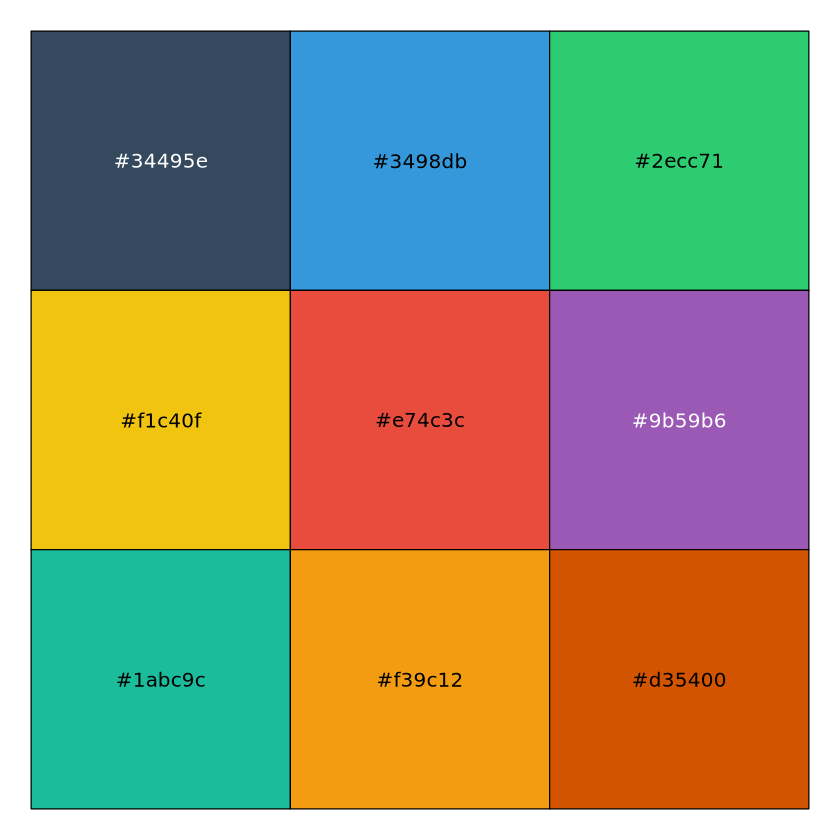

In [74]:
show_col(palettes_d$ggthemr$flat)

In [75]:
unique(all_correlations$Group)

[1] "5hmCG"      "5hmCG+5mCG" "5mCG"       "5hmCH"      "5hmCH+5mCH"
[6] "5mCH"

In [76]:
group.col <- setNames(rev(palettes_d$ggthemr$flat[1:6]),unique(all_correlations$Group))
group.col

5hmCG 5hmCG+5mCG       5mCG      5hmCH 5hmCH+5mCH       5mCH 
 "#9b59b6"  "#e74c3c"  "#f1c40f"  "#2ecc71"  "#3498db"  "#34495e"

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“Removed 1779 rows containing non-finite outside the scale range (`stat_density()`).”


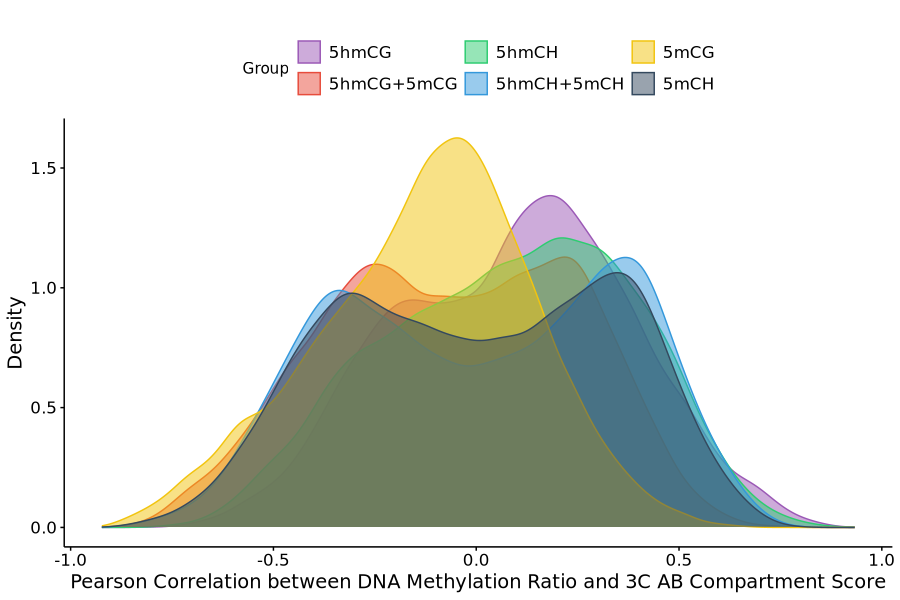

In [59]:
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 100)
ggplot(all_correlations, aes(x = correlation, fill = Group, color = Group)) +
  geom_density(alpha = 0.5) +
  theme_minimal() +
  labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = "Density"
  ) +
  scale_fill_manual(values = group.col) +
  scale_color_manual(values = group.col) +
  theme(
    legend.position = "top",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 0.5),
    axis.ticks = element_line(color = "black")
  )

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“Removed 1760 rows containing non-finite outside the scale range (`stat_density()`).”


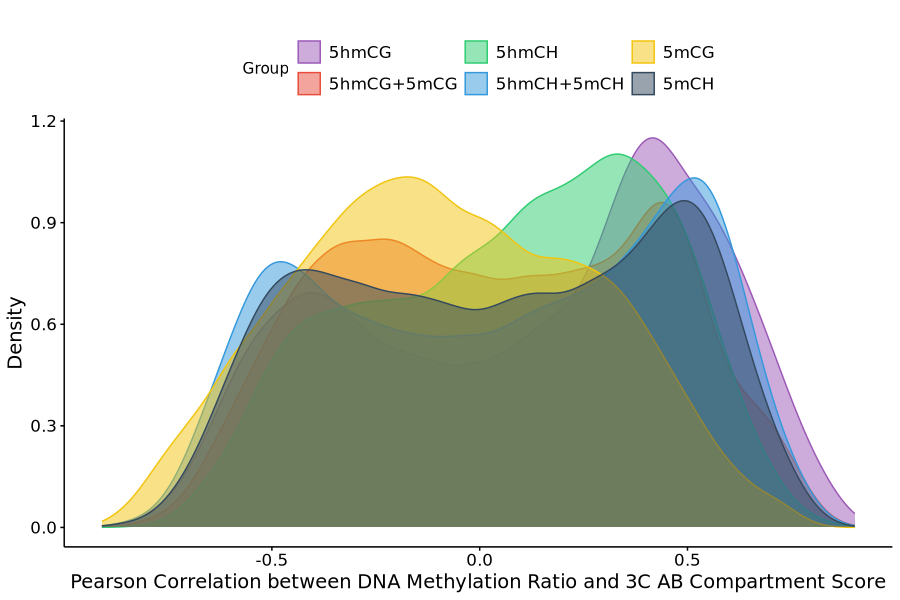

In [52]:
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 100)
ggplot(all_correlations, aes(x = correlation, fill = Group, color = Group)) +
  geom_density(alpha = 0.5) +
  theme_minimal() +
  labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = "Density"
  ) +
  scale_fill_manual(values = group.col) +
  scale_color_manual(values = group.col) +
  theme(
    legend.position = "top",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 0.5),
    axis.ticks = element_line(color = "black")
  )

In [52]:
# pic <- ggplot(all_correlations, aes(x = correlation, fill = Group, color = Group)) +
#   geom_density(alpha = 0.5) +
#   theme_minimal() +
#   labs(
#     title = "",
#     x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
#     y = "Density"
#   ) +
#   scale_fill_manual(values = group.col) +
#   scale_color_manual(values = group.col) +
#   theme(
#     legend.position = "top",
#     axis.title = element_text(color = "black", size = 14),
#     axis.text = element_text(color = "black", size = 12),
#     legend.text = element_text(color = "black", size = 12),
#     panel.grid.major = element_blank(),
#     panel.grid.minor = element_blank(),
#     panel.border = element_blank(),
#     axis.line = element_line(color = "black", size = 0.5),
#     axis.ticks = element_line(color = "black")
#   )

In [67]:
# pdf("../output/09-Pearson_Correlation_between_DNA_Methylation_Ratio_and_3C_AB_Compartment_Score.pdf",width = 9,height = 6)
# pic
# dev.off()

png 
  2

In [53]:
all_correlations

chrom100k,correlation,Group
<chr>,<dbl>,<chr>
chr1_100,-0.22392579,5hmCG
chr1_1000,0.57983399,5hmCG
chr1_1001,0.56180669,5hmCG
chr1_1002,0.51557755,5hmCG
chr1_1003,0.48640064,5hmCG
chr1_1004,0.46441721,5hmCG
chr1_1005,0.43992794,5hmCG
chr1_1006,0.47343730,5hmCG
chr1_1007,0.43105344,5hmCG


Warning message:
“Removed 1760 rows containing non-finite outside the scale range (`stat_density()`).”


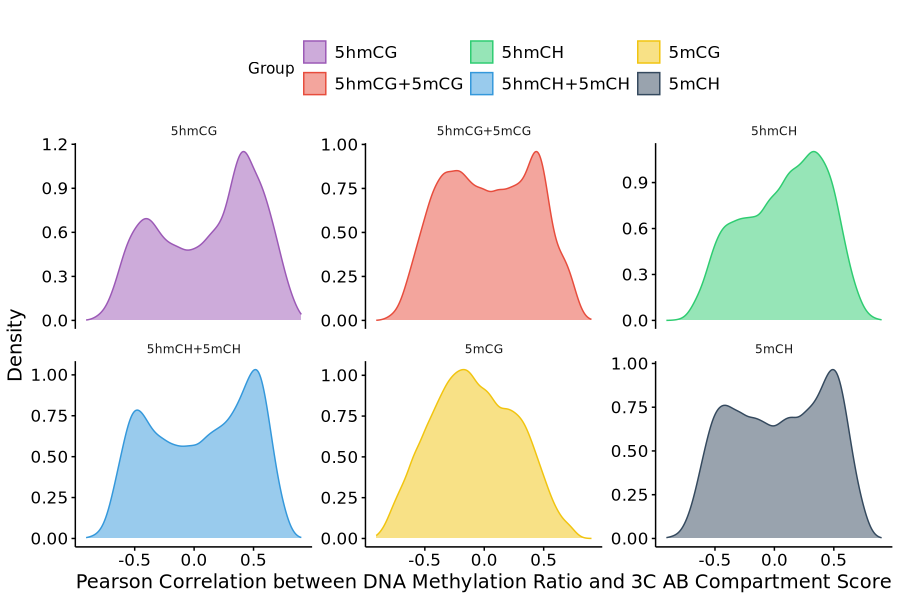

In [54]:
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 100)
ggplot(all_correlations, aes(x = correlation, fill = Group, color = Group)) +
  geom_density(alpha = 0.5) +
  facet_wrap(~ Group, scales = "free_y") +
  theme_minimal() +
  labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = "Density"
  ) +
  scale_fill_manual(values = group.col) +
  scale_color_manual(values = group.col) +
  theme(
    legend.position = "top",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 0.5),
    axis.ticks = element_line(color = "black")
  )

In [55]:
# pic2 <- ggplot(all_correlations, aes(x = correlation, fill = Group, color = Group)) +
#   geom_density(alpha = 0.5) +
#   facet_wrap(~ Group, scales = "free_y") +
#   theme_minimal() +
#   labs(
#     title = "",
#     x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
#     y = "Density"
#   ) +
#   scale_fill_manual(values = group.col) +
#   scale_color_manual(values = group.col) +
#   theme(
#     legend.position = "top",
#     axis.title = element_text(color = "black", size = 14),
#     axis.text = element_text(color = "black", size = 12),
#     legend.text = element_text(color = "black", size = 12),
#     panel.grid.major = element_blank(),
#     panel.grid.minor = element_blank(),
#     panel.border = element_blank(),
#     axis.line = element_line(color = "black", size = 0.5),
#     axis.ticks = element_line(color = "black")
#   )

In [55]:
# pdf("../output/09-Pearson_Correlation_between_DNA_Methylation_Ratio_and_3C_AB_Compartment_Score_split.pdf",width = 9,height = 6)
# pic2
# dev.off()

png 
  2

In [77]:
all_correlations

chrom100k,correlation,Group
<chr>,<dbl>,<chr>
chr1_100,0.27228924,5hmCG
chr1_1000,0.35201039,5hmCG
chr1_1001,0.33485536,5hmCG
chr1_1002,0.30591040,5hmCG
chr1_1003,0.30587751,5hmCG
chr1_1004,0.27381388,5hmCG
chr1_1005,0.22255811,5hmCG
chr1_1006,0.25612252,5hmCG
chr1_1007,0.19559169,5hmCG


In [78]:
unique(all_correlations$Group)

[1] "5hmCG"      "5hmCG+5mCG" "5mCG"       "5hmCH"      "5hmCH+5mCH"
[6] "5mCH"

In [79]:
levels(all_correlations$Group)

NULL

In [80]:
all_correlations$Group <- factor(all_correlations$Group,
                                 levels = c("5mCH","5hmCH+5mCH","5hmCH","5mCG","5hmCG+5mCG","5hmCG"))

In [81]:
levels(all_correlations$Group)

[1] "5mCH"       "5hmCH+5mCH" "5hmCH"      "5mCG"       "5hmCG+5mCG"
[6] "5hmCG"

In [82]:
library(ggridges)

Warning message:
“package ‘ggridges’ was built under R version 4.3.2”


In [83]:
mean_correlations <- all_correlations %>%
  group_by(Group) %>%
  summarize(mean_correlation = mean(correlation, na.rm = TRUE))
mean_correlations

Group,mean_correlation
<fct>,<dbl>
5mCH,0.001488125
5hmCH+5mCH,0.013310426
5hmCH,0.080378321
5mCG,-0.127061176
5hmCG+5mCG,-0.058861729
5hmCG,0.089254484


Picking joint bandwidth of 0.037

Warning message:
“Removed 1779 rows containing non-finite outside the scale range (`stat_density_ridges()`).”


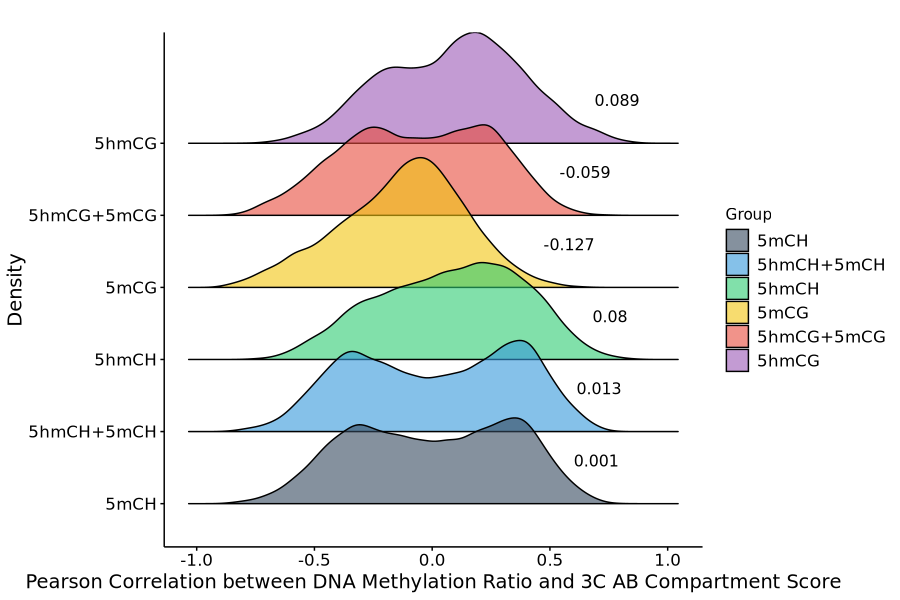

In [94]:
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 100)
ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
  geom_density_ridges2(alpha = 0.6) +
  scale_fill_manual(values = group.col) +
  geom_text(data = mean_correlations,
            aes(label = round(mean_correlation, 3), 
                x = mean_correlation + 0.6,  # 右移标签
                y = as.numeric(factor(Group)) + 0.6),  # 上移标签
            inherit.aes = FALSE, 
            hjust = 0, size = 4) +
  
  theme_classic() +
  labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = "Density"
  ) +
  theme(
    legend.position = "right",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 0.5),
    axis.ticks = element_line(color = "black")
  )

In [ ]:
pdf(paste0(outdir,"/10-Pearson_Correlation_between_DNA_Methylation_Ratio_and_3C_AB_Compartment_Score_density_ridges_20250116.pdf"),width = 6,height = 6)
ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
  geom_density_ridges2(alpha = 0.6) +
  scale_fill_manual(values = group.col) +
  geom_text(data = mean_correlations,
            aes(label = round(mean_correlation, 3), 
                x = mean_correlation + 0.6,  # 右移标签
                y = as.numeric(factor(Group)) + 0.6),  # 上移标签
            inherit.aes = FALSE, 
            hjust = 0, size = 4) +
  
  theme_classic() +
  labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = "Density"
  ) +
  theme(
    legend.position = "right",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 0.5),
    axis.ticks = element_line(color = "black")
  )
dev.off()

Picking joint bandwidth of 0.037

Warning message:
“Removed 1779 rows containing non-finite outside the scale range (`stat_density_ridges()`).”


png 
  2

Picking joint bandwidth of 0.037

Warning message:
“Removed 1779 rows containing non-finite outside the scale range (`stat_density_ridges()`).”


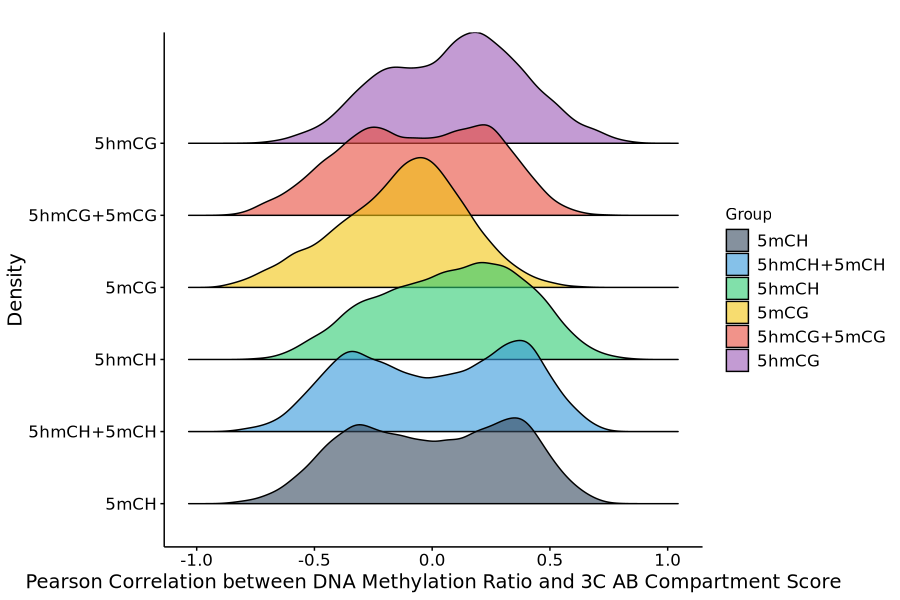

In [87]:
ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
geom_density_ridges2(alpha = 0.6) +
scale_fill_manual(values = group.col) +
theme_classic() +
labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = "Density"
  ) +
theme(
    legend.position = "right",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 0.5),
    axis.ticks = element_line(color = "black")
  )

In [66]:
pic3 <- ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
geom_density_ridges2(alpha = 0.6) +
scale_fill_manual(values = group.col) +
theme_classic() +
labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = "Density"
  ) +
theme(
    legend.position = "right",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 0.5),
    axis.ticks = element_line(color = "black")
  )

Picking joint bandwidth of 0.037

Warning message:
“Removed 1779 rows containing non-finite outside the scale range (`stat_density_ridges()`).”


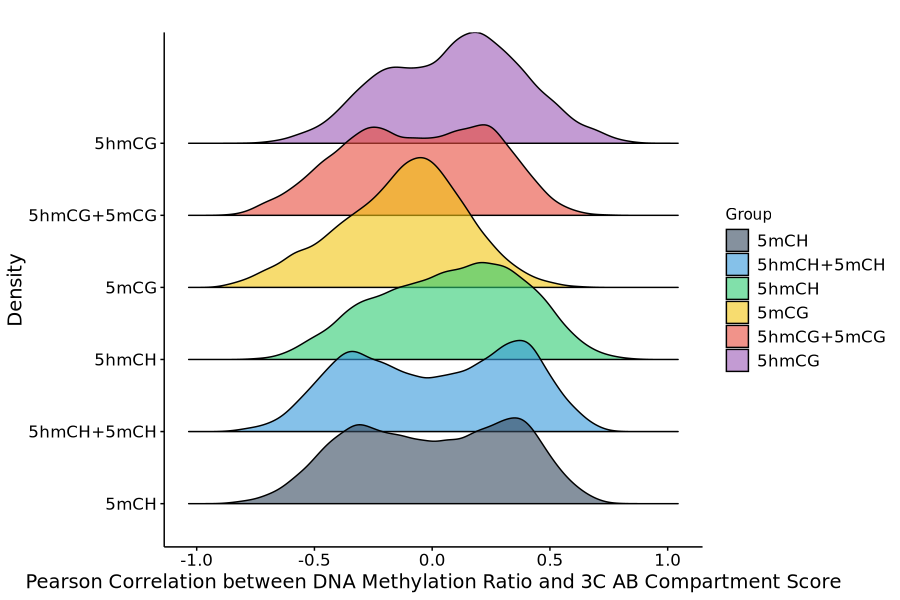

In [67]:
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 100)
pic3

In [61]:
pic3 <- ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
geom_density_ridges2(alpha = 0.6) +
scale_fill_manual(values = group.col) +
theme_classic() +
labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = "Density"
  ) +
theme(
    legend.position = "right",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 0.5),
    axis.ticks = element_line(color = "black")
  )

Picking joint bandwidth of 0.0462

Warning message:
“Removed 1760 rows containing non-finite outside the scale range (`stat_density_ridges()`).”


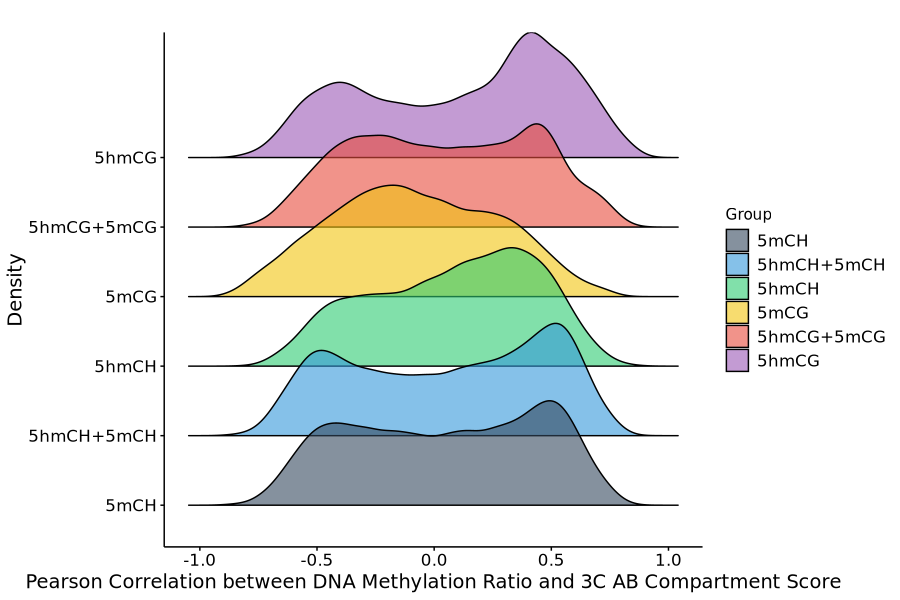

In [62]:
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 100)
pic3

Picking joint bandwidth of 0.0462

Warning message:
“Removed 1760 rows containing non-finite outside the scale range (`stat_density_ridges()`).”


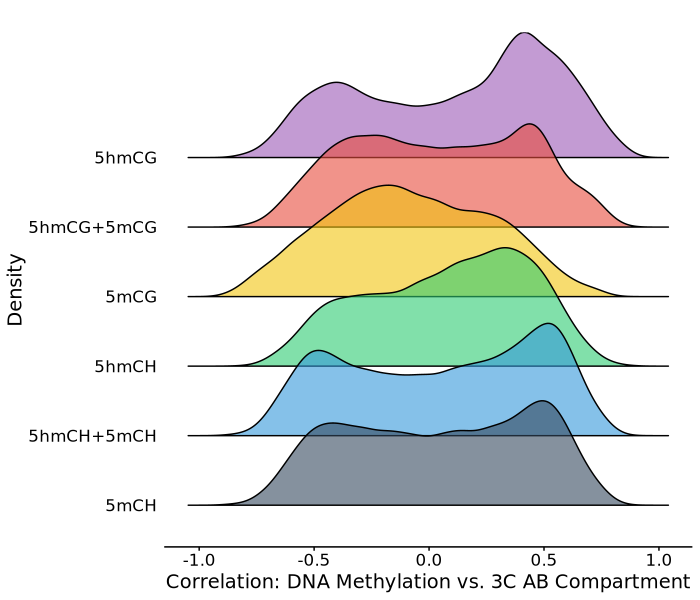

In [63]:
options(repr.plot.width = 7, repr.plot.height = 6, repr.plot.res = 100)
ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
  geom_density_ridges2(alpha = 0.6) +
  scale_fill_manual(values = group.col) +
  theme_classic() +
  labs(
    title = "",
    x = "Correlation: DNA Methylation vs. 3C AB Compartment",
    y = "Density"
  ) +
  theme(
    legend.position = "none",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line.x = element_line(color = "black", size = 0.5),
    axis.line.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.ticks.x = element_line(color = "black")
  )

Picking joint bandwidth of 0.0462

Warning message:
“Removed 1760 rows containing non-finite outside the scale range (`stat_density_ridges()`).”


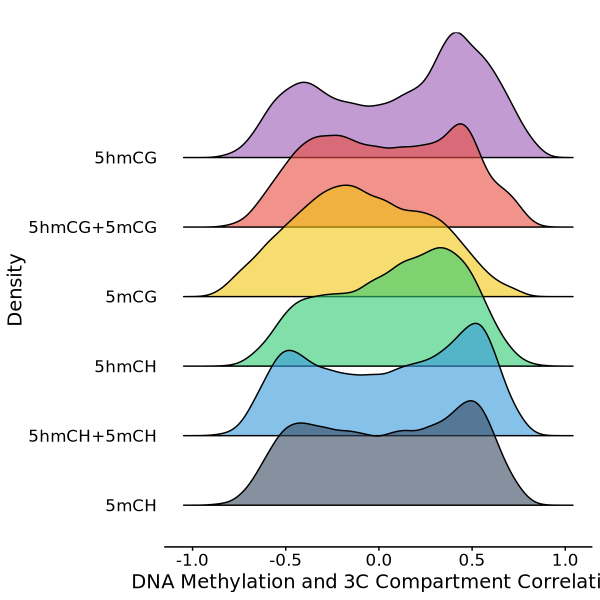

In [64]:
options(repr.plot.width = 6, repr.plot.height = 6, repr.plot.res = 100)
ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
  geom_density_ridges2(alpha = 0.6) +
  scale_fill_manual(values = group.col) +
  theme_classic() +
  labs(
    title = "",
    x = "DNA Methylation and 3C Compartment Correlation",
    y = "Density"
  ) +
  theme(
    legend.position = "none",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line.x = element_line(color = "black", size = 0.5),
    axis.line.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.ticks.x = element_line(color = "black")
  )

In [ ]:
pdf(paste0(outdir,"/10-Pearson_Correlation_between_DNA_Methylation_Ratio_and_3C_AB_Compartment_Score_density_ridges_20241229.pdf"),width = 6,height = 6)
ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
  geom_density_ridges2(alpha = 0.6) +
  scale_fill_manual(values = group.col) +
  theme_classic() +
  labs(
    title = "",
    x = "DNA Methylation and 3C Compartment Correlation",
    y = "Density"
  ) +
  theme(
    legend.position = "none",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line.x = element_line(color = "black", size = 0.5),
    axis.line.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.ticks.x = element_line(color = "black")
  )
dev.off()

Picking joint bandwidth of 0.0462

Warning message:
“Removed 1760 rows containing non-finite outside the scale range (`stat_density_ridges()`).”


png 
  2

In [ ]:
saveRDS(all_correlations,paste0(outdir,"/10-all_correlations_20241230.rds"))

In [ ]:
pdf("../../../output/01-youth/05-AB_compartment/10-Pearson_Correlation_between_DNA_Methylation_Ratio_and_3C_AB_Compartment_Score_density_ridges_20241230.pdf",width = 6,height = 6)
ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
  geom_density_ridges2(alpha = 0.6) +
  scale_fill_manual(values = group.col) +
  theme_classic() +
  labs(
    title = "",
    x = "DNA Methylation and 3C Compartment Correlation",
    y = "Density"
  ) +
  theme(
    legend.position = "none",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line.x = element_line(color = "black", size = 0.5),
    axis.line.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.ticks.x = element_line(color = "black")
  )
dev.off()

Picking joint bandwidth of 0.037

Warning message:
“Removed 1779 rows containing non-finite outside the scale range (`stat_density_ridges()`).”


png 
  2